In [1]:
import random

In [5]:
choices = [20, 14, 24, 7, 22, 16, 13, 10]
choices.remove(7)
random.shuffle(choices)
choices

[16, 22, 14, 10, 20, 24, 13]

16
22
14
10 Laptop

In [6]:
import yfinance as yf
import pandas as pd
import seaborn as sns

In [7]:
df = yf.download(["^GSPC", "NVDA"], interval="1d", period="1y")
df

[*********************100%%**********************]  2 of 2 completed


Adj Close                    Close                     High  \
                  NVDA        ^GSPC        NVDA        ^GSPC        NVDA   
Date                                                                       
2023-03-20  258.916962  3951.570068  259.000000  3951.570068  260.239990   
2023-03-21  261.905975  4002.870117  261.989990  4002.870117  263.920013   
2023-03-22  264.595123  3936.969971  264.679993  3936.969971  275.890015   
2023-03-23  271.822815  3948.719971  271.910004  3948.719971  274.989990   
2023-03-24  267.704132  3970.989990  267.790009  3970.989990  271.670013   
...                ...          ...         ...          ...         ...   
2024-03-14  879.440002  5150.479980  879.440002  5150.479980  906.460022   
2024-03-15  878.369995  5117.089844  878.369995  5117.089844  895.460022   
2024-03-18  884.549988  5149.419922  884.549988  5149.419922  924.049988   
2024-03-19  893.979980  5178.509766  893.979980  5178.509766  905.440002   
2024-03-20  886.245605  5174.720215  886.245605  5174.720215  904.099976   

                                Low                     Open               \
                  ^GSPC        NVDA        ^GSPC        NVDA        ^GSPC   
Date                                                                        
2023-03-20  3956.620117  251.300003  3916.889893  256.149994  3917.469971   
2023-03-21  4009.080078  253.809998  3971.189941  261.799988  3975.889893   
2023-03-22  4039.489990  262.369995  3936.169922  264.250000  4002.040039   
2023-03-23  4007.659912  266.899994  3919.050049  271.149994  3959.209961   
2023-03-24  3972.739990  263.549988  3909.159912  270.309998  3939.209961   
...                 ...         ...          ...         ...          ...   
2024-03-14  5176.850098  866.000000  5123.299805  895.770020  5175.140137   
2024-03-15  5136.859863  862.570007  5104.350098  869.299988  5123.310059   
2024-03-18  5175.600098  870.849976  5145.470215  903.880005  5154.770020   
2024-03-19  5180.310059  850.099976  5131.589844  867.000000  5139.089844   
2024-03-20  5184.879883  882.229980  5172.580078  898.900024  5181.689941   

              Volume              
                NVDA       ^GSPC  
Date                              
2023-03-20  43274700  5347140000  
2023-03-21  54740800  4920240000  
2023-03-22  79729500  4533010000  
2023-03-23  56488900  4991600000  
2023-03-24  45492000  4583970000  
...              ...         ...  
2024-03-14  60231800  4687970000  
2024-03-15  64019300  7753670000  
2024-03-18  66897600  4036220000  
2024-03-19  66972300  4031760000  
2024-03-20  24417349   913029045  

[253 rows x 12 columns]

In [10]:
df["Adj Close"].pct_change().std()

NVDA     0.029643
^GSPC    0.007383
dtype: float64

<Axes: xlabel='Date'>

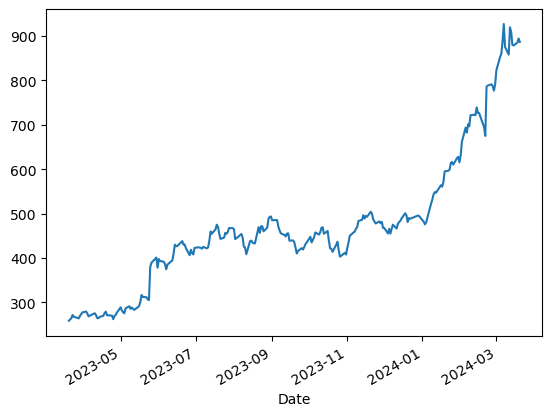

In [11]:
df["Adj Close"]["NVDA"].plot()

c:\Users\lcdstein.BABSON\.conda\envs\fdap310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


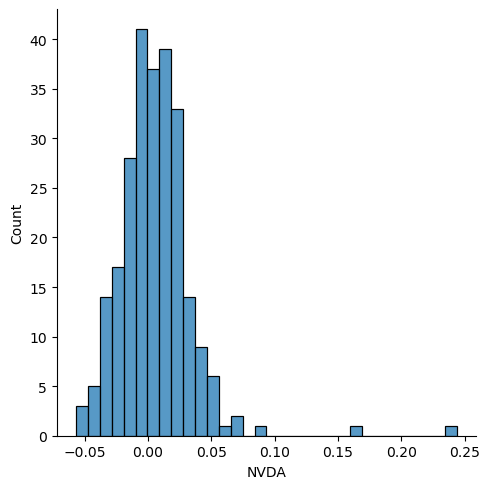

In [13]:
sns.displot(df["Adj Close"]["NVDA"].pct_change())

c:\Users\lcdstein.BABSON\.conda\envs\fdap310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


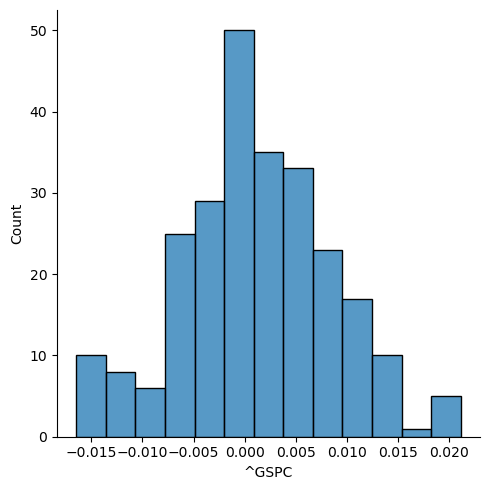

In [14]:
sns.displot(df["Adj Close"]["^GSPC"].pct_change())

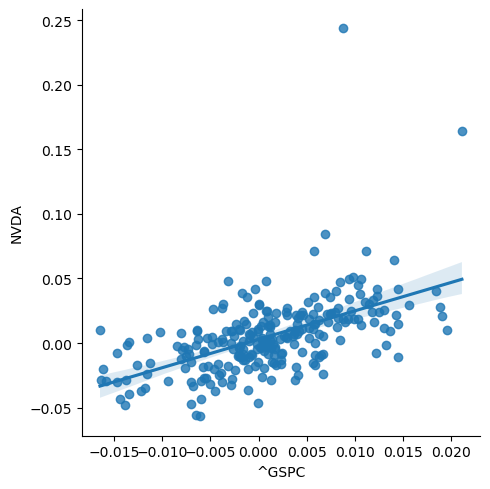

In [16]:
sns.lmplot(df["Adj Close"].pct_change(), x="^GSPC", y="NVDA")

In [17]:
df["Adj Close"].pct_change()

,NVDA,^GSPC
Date,,
2023-03-20,NaN,NaN
2023-03-21,0.011544,0.012982
2023-03-22,0.010268,-0.016463
2023-03-23,0.027316,0.002985
2023-03-24,-0.015152,0.005640
...,...,...
2024-03-14,-0.032392,-0.002871
2024-03-15,-0.001217,-0.006483
2024-03-18,0.007036,0.006318


In [21]:
abs(df["Adj Close"].pct_change()["NVDA"] - df["Adj Close"].pct_change()["^GSPC"]*3) > 0.05

Date
2023-03-20    False
2023-03-21    False
2023-03-22     True
2023-03-23    False
2023-03-24    False
              ...  
2024-03-14    False
2024-03-15    False
2024-03-18    False
2024-03-19    False
2024-03-20    False
Length: 253, dtype: bool

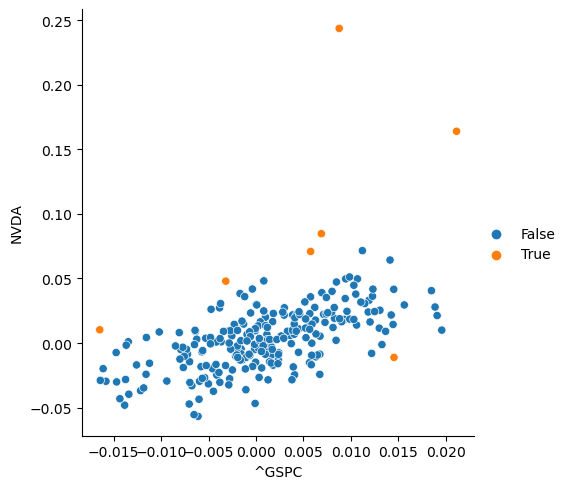

In [23]:
sns.relplot(data=df["Adj Close"].pct_change(), x="^GSPC", y="NVDA", hue=abs(df["Adj Close"].pct_change()["NVDA"] - df["Adj Close"].pct_change()["^GSPC"]*3) > 0.05)

In [30]:
df["Adj Close"].pct_change()["NVDA"]

Date
2023-03-20         NaN
2023-03-21    0.011544
2023-03-22    0.010268
2023-03-23    0.027316
2023-03-24   -0.015152
                ...   
2024-03-14   -0.032392
2024-03-15   -0.001217
2024-03-18    0.007036
2024-03-19    0.010661
2024-03-20   -0.008652
Name: NVDA, Length: 253, dtype: float64